# Hydrogenic Atoms

This assignment is designed to improve your intuition about 1-electron and many-electron atoms.


## &#x1f469;&#x1f3fd;&#x200d;&#x1f4bb; Assignment: Complete the Below Notebook

To do this, complete the code blocks indicated by `### START YOUR CODE HERE` and `### END YOUR CODE HERE` .

The detailed steps you'll follow are:

1. Plot the radial probabilities for the Hydrogenic orbitals.
1. Make contour plots of the 2p and 3d orbitals.
1. Compute the Coulomb repulsion between orbitals.


## Visualizing the Radial Probability Distribution for Hydrogenic Orbitals

Assuming the Born-Oppenheimer approximation, the Hamiltonian of 1-electron atom (in atomic units) is given by:

$$
\hat{H}_{\text{1 el. atom}} = -\frac{1}{2} \nabla^2 - \frac{Z}{r}
$$

The corresponding Schr&ouml;dinger equation in spherical coordinates is written as:

$$
\left(-\frac{1}{2} \left( \frac{d^2}{dr^2}
+ \frac{2}{r} \frac{d}{dr}\right)
      + \frac{\hat{L}^2}{2r^2} - \frac{Z}{r} \right)
      \psi_{n,l,m_l}(r,\theta,\phi)
= E_{n,l,m_l}\psi_{n,l,m_l}(r,\theta,\phi)
$$

Using the technique of separation of variables, the wave-function of 1-electron atom has the form:

$$
\psi_{n,l,m}(r,\theta,\phi) = R_{n,l}(r) Y_l^{m}(\theta,\phi)
$$

Solving the Schr&ouml;dinger equation, the eigenfunctions and eigenenergies of the 1-electron atoms are obtained. The radial and angular components of the wavefunction are discussed in the following sections which are described by quantum numbers

$$
\text{principle quantum number:} \quad n=1,2,3,\ldots \\
\text{angular momentum quantum number:} \quad l=0,1,\ldots,n-1 \\
\text{magnetic quantum number:} \quad m = 0,\pm 1, \pm2, \ldots, \pm l
$$

The eigenenergies of the 1-electron wavefunctions are

$$
E_n = -\frac{Z^2}{2n^2}
$$

The eigenenergies of the Hydrogenic wavefunctions do not depend on $m$ or $l$. So there are $(n+1)^2$ degenerate eigenfunctions.

For further review, see [The Schrödinger Wave Equation for the Hydrogen Atom](<https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Map%3A_Physical_Chemistry_for_the_Biosciences_(Chang)/11%3A_Quantum_Mechanics_and_Atomic_Structure/11.10%3A_The_Schrodinger_Wave_Equation_for_the_Hydrogen_Atom>).


### The radial component of the hydrogenic wavefunction is given by:

$$ R_{nl}(r) = \sqrt{\Big(\frac{2Z}{n a_0}\Big)^3 \frac{(n-l-1)!}{2n (n+l)!}} e^{-Zr/n a_0} \Big( \frac{2Zr}{na_0}\Big)^l \cdot L^{2l+1}_{n-l-1} \Big(\frac{2Zr}{n a_0} \Big)$$

- $R_{nl}(r)$ has $(n - l - 1)$ nodes.
- The $L$ denotes the [associated Laguerre polynomials](https://en.wikipedia.org/wiki/Laguerre_polynomials) computed by [scipy.special.assoc_laguerre](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.assoc_laguerre.html).
- The Bohr radius (atomic unit of length) is one; i.e., $a_0=1$.

For further review, see [Radial and Angular Parts of Atomic Orbitals](<https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Quantum_Mechanics/10%3A_Multi-electron_Atoms/Radial_and_Angular_Parts_of_Atomic_Orbitals>).


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import special

In [12]:
def radial(r, n, l, Z=2):
    """
    Compute the radial part of the hydrogenic wavefunction.

    Parameters
    ----------
    r : float
        The radial distance from the nucleus.
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    Z : int
        The atomic number.

    Returns
    -------
    float
        The value of the radial wavefunction at r.
    """
    ## computing normalization constant

    ### START YOUR CODE HERE ###
    norm = np.sqrt(
        (2 * Z / n)**3 * special.factorial(n-l-1)/(2*n*special.factorial(n+l))
    )

    ## computing exponent
    exp = np.exp(-Z * r / n)

    ## computing polynomial
    polynomial = (2 * Z * r / n)**l

    ##computing Laguerre
    lag = special.assoc_laguerre(2 * Z * r/n, n - l - 1, 2*l + 1)

    return norm * exp * polynomial * lag
    ### END YOUR CODE HERE ###

def compute_radial_prob(r, n, l, Z=2):
    """
    Compute the radial probability density of the hydrogenic wavefunction.

    Parameters
    ----------
    r : float
        The radial distance from the nucleus.
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    Z : int
        The atomic number.

    Returns
    -------
    float
        The probability density at r.
    """
    ### START YOUR CODE HERE ###
    ## computing probability density
    return radial(r, n, l, Z)**2 * 4*np.pi * r**2
    ### END YOUR CODE HERE ###

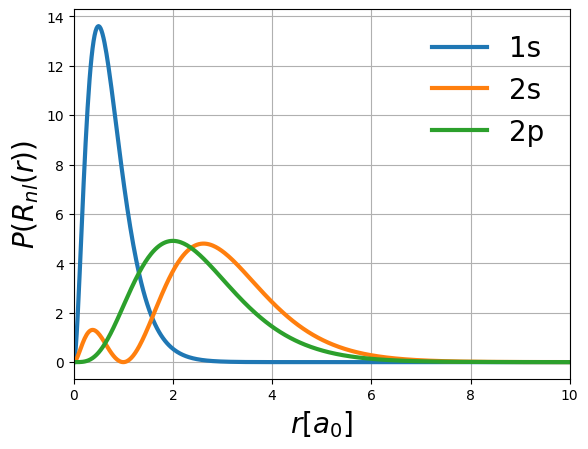

In [13]:
r = np.linspace(0, 20, 1000)

# plot r vs. prob R(r)
plt.plot(r, compute_radial_prob(r, n=1, l=0), lw=3, label="1s")
plt.plot(r, compute_radial_prob(r, n=2, l=0), lw=3, label="2s")
plt.plot(r, compute_radial_prob(r, n=2, l=1), lw=3, label="2p")

plt.xlabel("$r [a_0]$",fontsize=20)
plt.ylabel("$P(R_{nl}(r))$", fontsize=20)
plt.grid("True")
plt.legend(frameon=False, fontsize=20)
plt.xlim(0, 10)
plt.show()

## Visualizing the Angular Wavefunction for Hydrogenic Orbitals

The angular component of the hydrogenic wavefunction is given by spherical harmonics:

$$
Y_{lm}(\theta,\phi) = \Theta_{lm}(\theta) \Phi_m (\phi) = \sqrt{\frac{2l+1}{4\pi} \frac{(l-m)!}{(l+m)!} } P_{lm}(cos \theta) \cdot e^{im\phi}
$$

- $Y_{lm}(\theta,\phi)$ has $l$ nodes.
- The $P$ are the associated Legendre functions.
- The spherical harmonics are computed by [scipy.special.sph_harm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.sph_harm.html).

For further review, see [Radial and Angular Parts of Atomic Orbitals](<https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Quantum_Mechanics/10%3A_Multi-electron_Atoms/Radial_and_Angular_Parts_of_Atomic_Orbitals>).

**Note:** that the orbital images that appear above do not look that much like the usual orbital pictures, with the exception of the $m=0$ orbitals. This is because of the complex-valuedness. We often instead use the _real_ spherical harmonics, which are defined simply as:

$$
\begin{align}
S_l^{m>0}(\theta,\phi) &= \frac{1}{\sqrt{2}} \left(Y_l^{-m} (\theta, \phi) + (-1)^{m} Y_l^{m} (\theta, \phi) \right) \\
S_l^{m=0}(\theta,\phi) &= Y_l^{m=0} (\theta, \phi) \\
S_l^{m<0}(\theta,\phi) &= \frac{i}{\sqrt{2}} \left(Y_l^{-m} (\theta, \phi) - (-1)^{m} Y_l^{m} (\theta, \phi) \right)
\end{align}
$$

The following animations shows one can take linear combinations of the (complex) spherical harmonics to form the $p_x$, $p_y$, etc. orbitals one generally uses in chemistry.

![animation of 2p orbital](https://github.com/PaulWAyers/IntroQChem/blob/main/linkedFiles/Orbital_p1-px_animation.gif?raw=true "animation of 2p real and complex orbitals; by Geek3 CC-SA4 license")

![animation of 3p orbital](https://github.com/PaulWAyers/IntroQChem/blob/main/linkedFiles/Orbital_3p1-3px_animation.gif?raw=true "animation of 3p real and complex orbitals; by Geek3 CC-SA4 license")

Using the [orbitron](https://winter.group.shef.ac.uk/orbitron/atomic_orbitals/7i/index.html), you can visualize the (real, Cartesian) spherical harmonics.


In [14]:
def spherical(theta, phi, l, m):
    """
    Compute the spherical harmonic function.

    Parameters
    ----------
    theta : float
        The polar angle.
    phi : float
        The azimuthal angle.
    l : int
        The angular momentum quantum number.
    m : int
        The magnetic quantum number.

    Returns
    -------
    harm: complex
        The value of the spherical harmonic function at given theta and phi.
    """
    ### START YOUR CODE HERE ###
    # calculating the spherical harmonic function using scipy.special.sph_harm
    harm = special.sph_harm(m, l, phi, theta)
    return harm
    ### END YOUR CODE HERE ###

def hydrogenic_wavefunction(r, theta, phi, n, l, m, Z=2):
    """
    Compute the hydrogenic wavefunction.

    Parameters
    ----------
    r : float
        The radial distance from the nucleus.
    theta : float
        The polar angle.
    phi : float
        The azimuthal angle.
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    m : int
        The magnetic quantum number.
    Z : int
        The atomic number.

    Returns
    -------
    float
        The value of the hydrogenic wavefunction at given r, theta, and phi.
    """
    ### START YOUR CODE HERE ###
    # compute the wavefunction using the radial and spherical part
    return radial(r, n, l,Z)*spherical(theta, phi, l, m)
    ### END YOUR CODE HERE ###

/tmp/ipykernel_5322/600684254.py:23: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  harm = special.sph_harm(m, l, phi, theta)


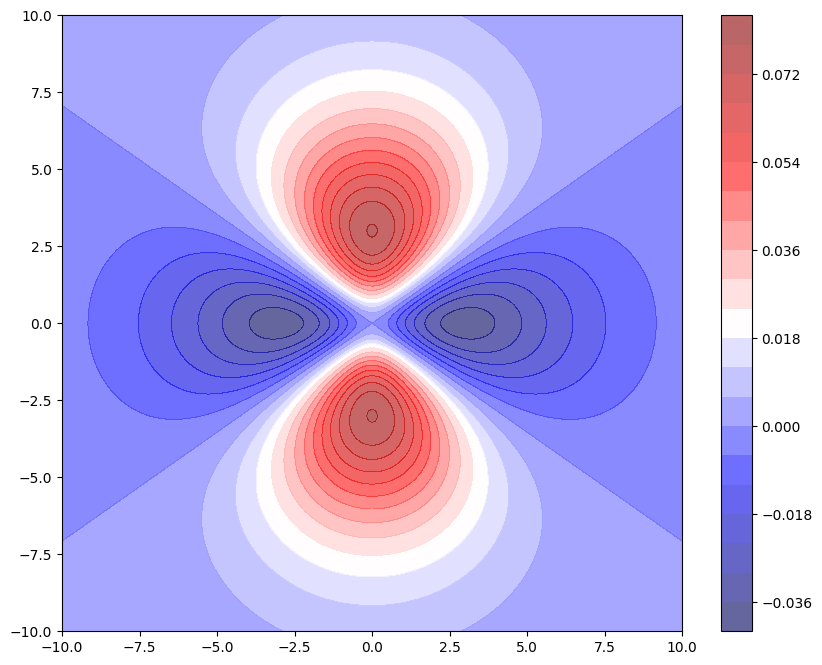

In [15]:
def psi_xz_plot(n=1, l=0, m=0, N=500):
    """
    Plot the hydrogenic wavefunction in the xz-plane.

    Parameters
    ----------
    n : int
        The principal quantum number.
    l : int
        The angular momentum quantum number.
    m : int
        The magnetic quantum number.
    N : int
        The number of points on the grid.

    Returns
    -------
    None
    """

    plt.figure(figsize=(10, 8))
    limit = 2 * (n + l)

    # create a grid of points in the xz-plane
    ### START YOUR CODE HERE ###
    # create array of uniformly spaced points in x and z
    # from -limit to limit with 500 points
    x_1d = np.linspace(-limit, limit, N)
    z_1d = np.linspace(-limit, limit, N)

    # create a 2D meshgrid for the x and z points
    x, z = np.meshgrid(x_1d, z_1d)
    y = 0

    # convert the 2D meshgrid to spherical coordinates
    r = np.sqrt(x**2 + y**2 + z**2 )
    theta = np.arccos(z/r)
    phi = np.arctan2(y, x)

    # compute the real part of hydrogenic wavefunction
    psi_nlm = hydrogenic_wavefunction(r, theta, phi, n, l, m)
    prob = np.abs(psi_nlm)**2

    ### END YOUR CODE HERE ###
    # classic orbitals
    plt.contourf(x, z, psi_nlm, 20, cmap="seismic", alpha=0.6)  # Classic orbitals
    plt.colorbar()

    return psi_nlm

psi = psi_xz_plot(3, 2, 0) ################################ MISTAKE WRONG ARGUEMENTS

## Compute the Coulomb Repulsion Between two Hydrogenic Orbitals

3. The Coulomb and exchange integrals determine the effect of electron repulsion on
   the excited states of helium. For example, for the 1s12s1 electron configuration, we have
   $$
   J_{1 \mathrm{~s}, 2 \mathrm{~s}}=\int \frac{(1 \mathrm{~s})^2\left(\mathbf{x}_1\right)(2 \mathrm{~s})^2\left(\mathbf{x}_2\right)}{r_{12}} d \mathbf{x}_1 d \mathbf{x}_2
   $$


This is a six dimensional integral. However, it can be simplified via the Laplace
expansion of $\frac{1}{r_{12}}$,

$$
\frac{1}{r_{12}}=\frac{1}{\left\|\mathbf{x}_1-\mathbf{x}_2\right\|}=\sum_{\ell=0}^{\infty} \frac{4 \pi}{2 \ell+1} \sum_{m_l=-\ell}^{\ell}(-1)^{m_{\ell}} \frac{r_{<}^{\ell}}{r_{>}^{\ell+1}} Y_{\ell, m_{\ell}}^*\left(\theta_1, \phi_1\right) Y_{\ell, m_{\ell}}\left(\theta_2, \phi_2\right)
$$

Substituting this expression into the above matrix elements allows the electron 1 and 2
integrals to be evaluated independently. Moreover, the radial and angular integrals are also
separated. Finally, the resulting angular matrix elements - here, of the form, $\left\langle Y_{0,0} \mid Y_{l, m} | Y_{0,0}\right\rangle$
, can be evaluated analytically. First, only the m = 0 term is non-zero. This is because the integral is otherwise zero. Next, since $Y_{0,0}$, is real and


$$
Y_{0,0}^2(\theta, \phi)==(4 \pi)^{-1}=(4 \pi)^{-1 / 2} Y_{0,0}(\theta, \phi)
$$

the above matrix element reduces to


$$
\begin{aligned}
& \left\langle Y_{0,0} \mid Y_{\ell, 0} |Y_{0,0}\right\rangle=(4 \pi)^{-1 / 2}\left\langle Y_{0,0} \mid Y_{\ell, 0}\right\rangle \\
& =\begin{array}{cc}
(4 \pi)^{-1 / 2} & \ell=0 \\
0 & \text { otherwise }
\end{array} \\
&
\end{aligned}
$$
Thus,
$$

\begin{aligned}
& =\int_0^{\infty} \int_0^{\infty} \frac{1}{r_{>}} R_{1,0}^2\left(r_1\right) R_{2,0}^2\left(r_2\right) r_1^2 r_2^2 d r_1 d r_2 \\
&
\end{aligned}

$$
and
$$

K_{1 \mathrm{~s}, 2 \mathrm{~s}}=\int_0^{\infty} \int_0^{\infty} \frac{1}{r_{>}} R_{1,0}\left(r_1\right) R_{2,0}\left(r_1\right) R_{1,0}\left(r2\right) R_{2,0}\left(r_2\right) r_1^2 r_2^2 d r_1 d r_2 .
$$


In [16]:
def J_1s2s(r1, r2):
    """
    Compute the Coulomb integral between the 1s-2s orbitals.

    Parameters
    ----------
    r1 : float
        The radial distance from the nucleus for the first electron.
    r2 : float
        The radial distance from the nucleus for the second electron.

    Returns
    -------
    float
        The value of the Coulomb integral between the 1s-2s orbitals.
    """

    ### create a grid
    r1, r2 = np.meshgrid(r1, r2)

    ### START YOUR CODE HERE ###
    ### evaluate square values of r1 and r2
    r1_2 = r1**2
    r2_2 = r2**2

    ### evaluate the radial components
    R_10 = radial(r1, 1, 0)
    R_20 = radial(r2, 2, 0)
    ### evaluate the maximum radial component
    r_max = np.maximum(r1, r2)

    ### return the final values on the grid
    return R_10**2 * R_20**2 * r1_2 * r2_2 / r_max
    ### END YOUR CODE HERE ###


def integrate_grid(grid_func, rmin=1e-22, rmax=50, n_points=1000):
    """
    Integrate a given grid function.

    Parameters
    ----------
    grid_func : function
        The function to be integrated.
    rmin : float
        The minimum value of the radial distance.
    rmax : float
        The maximum value of the radial distance.
    n_points : int
        The number of points in the grid.

    Returns
    -------
    float
        The value of the integral.
    """
    ### create vectors  r1 and r2  of size n_points ranging from rmin to rmax
    r1 = np.linspace(rmin, rmax, n_points)
    r2 = np.linspace(rmin, rmax, n_points)

    ### START YOUR CODE HERE ###
    ### evaluate the grid for the specified grid function
    grid = grid_func(r1, r2)
    plt.imshow(grid)
    plt.show()

    ### calculate the dr1 and dr2
    dr1 = r1[1] - r1[0]
    dr2 = r2[1] - r2[0]

    ### perform integration by suming up all the values on the grid
    ### and multiply them by dr1 and dr2
    result = np.sum(grid)*dr1*dr2

    return result
    ### END YOUR CODE HERE ###

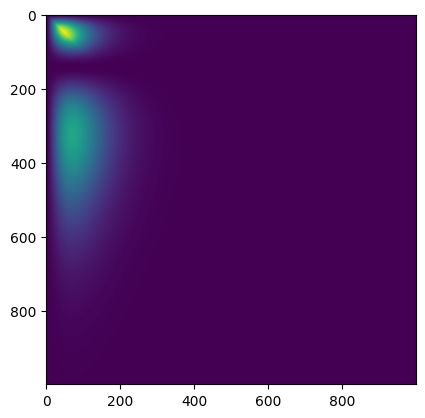

Computed Coulomb integral:  0.41922171201708963


In [17]:
result_J_1s2s = integrate_grid(J_1s2s, rmin=1e-22, rmax=7, n_points=1000) ######## MISTAKE rmax should be 7
print("Computed Coulomb integral: ", result_J_1s2s)

# The exact answer is 0.42. When I increase limit of integration it gives close to the correct result:
# rmax = 10 -> 0.419752
# rmax = 100 -> 0.4200
# However, if I change rmax = 500, the result is 0.38. What's going on and how to fix it?

### &#x1f914; Thought-Provoking Questions

- Referring to the radial probability distributions for the orbitals, why is the 2s energy lower in energy than the 2p energy for many-electron atoms? Can you propose a _numerical_ approach that would allow you to test this hypothesis?
- Compute the Coulomb repulsion between a 2s and 2p orbital. How does this compare to the Coulomb repulsion between the 1s and 2p orbital, and between the 1s and 2s orbitals? Does the result make sense?


## &#x2696;&#xfe0f; Marking Scheme

&#x2611;&#xfe0f; Successful completion of the notebook, together with the ability to discuss your strategy, earns an **S**.

&#x1f4b0; For an **S+**,

- answer all of the thought-provoking questions.
  Add markdown cells and/or code to complete these tasks. You can add images of hand-written answers to the markdown cells if you prefer, but write neatly.


### &#x1f914;  **Answers**

- Referring to the radial probability distributions for the orbitals, why is the 2s energy lower in energy than the 2p energy for many-electron atoms? Can you propose a _numerical_ approach that would allow you to test this hypothesis?

The 2s orbital has an inner radial node that penetrates closer to the nucleus than 2p. This means 2s electrons spend more time near the nucleus, inside the shielding cloud of 1s electrons. 2p has no inner lobe; it is more effectively shielded by the 1s electrons. Therefore $Z_{\text{eff}}^{2s} > Z_{\text{eff}}^{2p}$, lowering the 2s energy

**Numerical approach:**

A numerical test would be to solve the Hartree-Fock equations for a many-electron atom
(e.g. lithium or carbon) and compute the expectation value of the effective potential
felt by a 2s versus a 2p electron:

$$Z_{\text{eff}} = \langle \psi | \hat{Z}_{\text{eff}}(r) | \psi \rangle = Z - \langle \psi | \hat{\sigma}(r) | \psi \rangle$$

where $\hat{\sigma}(r)$ is the shielding operator from all other electrons. By numerically
integrating the radial probability distributions $r^2|R_{nl}(r)|^2$ for the 2s and 2p
orbitals, we can compute the probability of each orbital penetrating inside the 1s
shell (i.e. $r < r_{1s}^{\text{max}}$). The orbital with greater inner penetration
experiences less shielding and lower energy. We would expect:

$$\int_0^{r_{1s}} r^2|R_{2s}(r)|^2 \, dr > \int_0^{r_{1s}} r^2|R_{2p}(r)|^2 \, dr$$

confirming that 2s penetrates more and is lower in energy.
- Compute the Coulomb repulsion between a 2s and 2p orbital. How does this compare to the Coulomb repulsion between the 1s and 2p orbital, and between the 1s and 2s orbitals? Does the result make sense?

Both approaches confirm $E_{2s} < E_{2p}$: the former Hartree-Fock argument via effective nuclear charge explains it intuitively: the 2s orbital penetrates closer to the nucleus, experiencing a stronger effective attraction, while this latter Coulomb repulsion integrals provide a direct numerical proof by explicitly quantifying the electron-electron repulsion each orbital experiences. The former is more straightforward to interpret physically, but the latter more precisely describes the underlying mechanism driving the energy splitting.

The previous question approached the $E_{2s} < E_{2p}$ splitting conceptually via the radial probability distributions and the notion of orbital penetration.Here, I provide a direct numerical confirmation using the J functions from this notebook:

$$J(a,b) = \int_0^\infty \int_0^\infty r_1^2 r_2^2 |R_a(r_1)|^2 \frac{1}{r_>} |R_b(r_2)|^2 \, dr_1 \, dr_2$$
**Calculations were made in the code cell below**

The output:

J(1s, 2s) = 0.4198 Hartree

J(1s, 2p) = 0.4856 Hartree

J(2s, 2p) = 0.3242 Hartree

Note that these values use $Z=2$ (helium) from the default in `radial()`. The ordering is what matters and it is exactly correct:

$$J(2s, 2p) < J(1s, 2s) < J(1s, 2p)$$

This directly supports the $E_{2s} < E_{2p}$ argument wherein the 2s orbital experiences less repulsion from the core 1s electrons than 2p does, and simultaneously penetrates closer to the nucleus due to its inner radial lobe. Both effects conspire to lower the 2s energy below 2p.

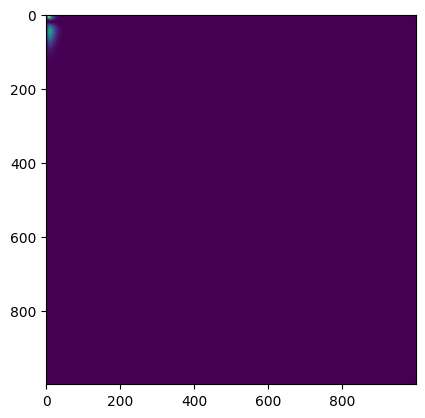

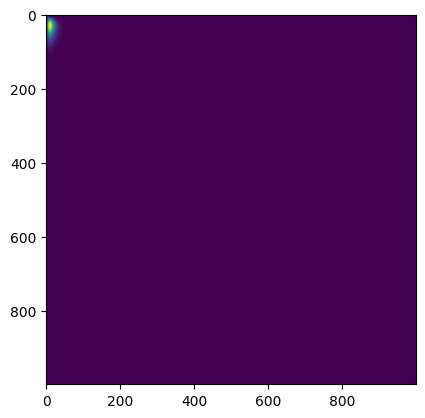

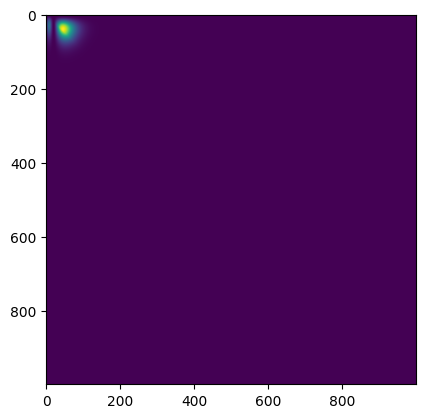

J(1s, 2s) = 0.4198 Hartree
J(1s, 2p) = 0.4856 Hartree
J(2s, 2p) = 0.3242 Hartree


In [18]:
def J_1s2p(r1, r2):
    r1, r2 = np.meshgrid(r1, r2)
    r1_2 = r1**2
    r2_2 = r2**2
    R_10 = radial(r1, 1, 0)
    R_21 = radial(r2, 2, 1)
    r_max = np.maximum(r1, r2)
    return R_10**2 * R_21**2 * r1_2 * r2_2 / r_max


def J_2s2p(r1, r2):
    r1, r2 = np.meshgrid(r1, r2)
    r1_2 = r1**2
    r2_2 = r2**2
    R_20 = radial(r1, 2, 0)
    R_21 = radial(r2, 2, 1)
    r_max = np.maximum(r1, r2)
    return R_20**2 * R_21**2 * r1_2 * r2_2 / r_max

## I edited the integrate_grid function so it can take any grid (it was hard-coded before)

J1s2s_val = integrate_grid(J_1s2s)
J1s2p_val = integrate_grid(J_1s2p)
J2s2p_val = integrate_grid(J_2s2p)

print(f"J(1s, 2s) = {J1s2s_val:.4f} Hartree")
print(f"J(1s, 2p) = {J1s2p_val:.4f} Hartree")
print(f"J(2s, 2p) = {J2s2p_val:.4f} Hartree")